In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

In [2]:
# Some functions for plotting. You don't have to understand how any
# of the functions in this cell work, since they use things we 
# haven't learned about in DSCI 100.

def resize_window(lim=3.5):
    plots.xlim(-lim, lim)
    plots.ylim(-lim, lim)
    
def draw_line(slope=0, intercept=0, x=make_array(-4, 4), color='r'):
    y = x*slope + intercept
    plots.plot(x, y, color=color)
    
def draw_vertical_line(x_position, color='black'):
    x = make_array(x_position, x_position)
    y = make_array(-4, 4)
    plots.plot(x, y, color=color)
    
def make_correlated_data(r):
    x = np.random.normal(0, 1, 1000)
    z = np.random.normal(0, 1, 1000)
    y = r*x + (np.sqrt(1-r**2))*z
    return x, y

def r_table(r):
    """
    Generate a table of 1000 x,y data points in standard units
    whose correlation is approximately equal to r
    """
    np.random.seed(8)
    x, y = make_correlated_data(r)
    return Table().with_columns('x', x, 'y', y)

In [3]:
def demographics_errors(slope, intercept):
    # Use four convenient points from the original data
    sample = [[14.7, 33995], [19.1, 61454], [50.7, 71183], [59.5, 105918]]
    demographics.scatter('College%', 'Median Income', alpha=0.5)
    xlims = make_array(5, 75)
    # Plot a line with the slope and intercept you specified:
    plots.plot(xlims, slope * xlims + intercept, lw=4)
    # Plot red lines from each of the four points to the line
    for x, y in sample:
        plots.plot([x, x], [y, slope * x + intercept], color='r', lw=4)

In [4]:
def show_demographics_rmse(slope, intercept):
    demographics_errors(slope, intercept)
    x = demographics.column('College%')
    y = demographics.column('Median Income')
    prediction = slope * x + intercept
    mse = np.mean((y - prediction) ** 2)
    print("Root mean squared error:", round(mse ** 0.5, 2))

In [5]:
def fitted_values(t, x, y):
    """Return an array of the regressions estimates at all the x values"""
    a = slope(t, x, y)
    b = intercept(t, x, y)
    return a*t.column(x) + b

## Slope & Intercept

Brings in the functions from Lecture 29 and 30 that converted to standard units, found the r for two variables, and found the slope and intercept for the linear regression model.

In [6]:
def standard_units(x):
    """Converts an array x to standard units"""
    return (x - np.mean(x)) / np.std(x)

def correlation(t, x, y):
    x_su = standard_units(t.column(x))
    y_su = standard_units(t.column(y))
    return np.mean(x_su * y_su)


In [7]:
def slope(t, x, y):
    """ Computes the slope of the regression line, like correlation above """
    r = correlation(t, x, y)
    y_sd = np.std(t.column(y))
    x_sd = np.std(t.column(x))
    return r * y_sd / x_sd

    
def intercept(t, x, y):
    """ Computes the intercept of the regression line, like slope above """
    x_mean = np.mean(t.column(x))
    y_mean = np.mean(t.column(y))
    return y_mean - slope(t, x, y)*x_mean

In [8]:
# RUN to show that the function works for the ficticious data created with an r of 0.5.

example = r_table(0.5)
slope(example, 'x', 'y')

0.50226382816259152

## Heights data

Import the data from the families table and describe the table. 

In [9]:
families = Table.read_table('heights.csv')

heights = Table().with_columns(
    'MidParent', families.column('midparentHeight'),
    'Child', families.column('childHeight'))
heights

MidParent,Child
75.43,73.2
75.43,69.2
75.43,69
75.43,69
73.66,73.5
73.66,72.5
73.66,65.5
73.66,65.5
72.06,71
72.06,68


In [10]:
def nn_prediction_heights(h):
    """
    Return a prediction of the height of a child 
    whose parents have a midparent height of h.
    
    The prediction is the average height of the children 
    whose midparent height is in the range h plus or minus 0.5 inches.
    """
    neighbors = heights.where(
        'MidParent', are.between(h - 0.5, h + 0.5))
    return np.mean(neighbors.column('Child'))

In [11]:
# COMPLETE: Create a new table that adds the Average neighbor prediction as a column. 
heights_with_predictions = heights.with_column(
    'Average neighbor prediction',
    heights.apply(nn_prediction_heights, 'MidParent')
)
heights_with_predictions.show(3)

MidParent,Child,Average neighbor prediction
75.43,73.2,70.1
75.43,69.2,70.1
75.43,69,70.1


In [12]:
# COMPLETE: Calculate the slope and intercept for the model and display both. 

heights_slope = slope(heights, 'MidParent', 'Child')
heights_intercept = intercept(heights, 'MidParent', 'Child')
heights_slope, heights_intercept

(0.63736089696947895, 22.636240549589751)

***QUESTION: How would you write these values as a linear regression model?***

$y = 0.64x + 22.64$

***QUESTION: How would you interpret the slope and intercept in the context of the data?***

***QUESTION: Does the y-intercept make sense as a data point?***


In [13]:
# COMPLETE: Add the Regression Prediction to the table. 
heights_with_predictions = heights_with_predictions.with_column(
    'Regression Prediction', 
    heights_slope * heights.column('MidParent') + heights_intercept
)
heights_with_predictions

MidParent,Child,Average neighbor prediction,Regression Prediction
75.43,73.2,70.1,70.7124
75.43,69.2,70.1,70.7124
75.43,69,70.1,70.7124
75.43,69,70.1,70.7124
73.66,73.5,70.4158,69.5842
73.66,72.5,70.4158,69.5842
73.66,65.5,70.4158,69.5842
73.66,65.5,70.4158,69.5842
72.06,71,68.5025,68.5645
72.06,68,68.5025,68.5645


***QUESTION: What do you notice about the nearest neighbor prediction and the linear regression model values?***



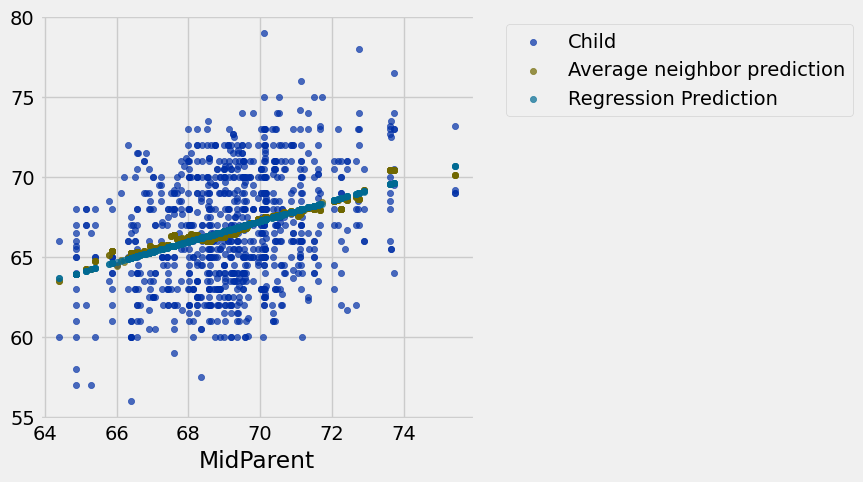

In [14]:
heights_with_predictions.scatter('MidParent')

### Discussion Question

A course has a midterm (average 70; standard deviation 10) and a really hard final (average 50; standard deviation 12).

If the scatter diagram comparing midterm & final scores for students has an oval shape with correlation 0.75, then...

* What do you expect the average final score would be for students who scored 90 on the midterm?
* How about 60 on the midterm?


In [15]:
# Creating the above scenario with variables. 
mean_x = 70 
sd_x = 10
mean_y = 50
sd_y = 12

r = 0.75

#Question 1
x = 90

num_sds_x = (x - mean_x)/sd_x
num_sds_y_estimate = r * num_sds_x

y_pred = num_sds_y_estimate * sd_y + mean_y

y_pred

68.0

In [16]:
# Using linear regression, find the slope and the intercept to predict y.

slope2 = r * sd_y/sd_x

#y = mx + b

slope2 * 90 + (mean_y - slope2 * mean_x)


68.0

In [18]:
# COMPLETE: Predict the answer for 60 on the midterm. 
x = 60

num_sds_x = (x - mean_x)/sd_x
num_sds_y_estimate = r * num_sds_x

y_pred = num_sds_y_estimate * sd_y + mean_y

y_pred

41.0

### Error in Estimation

Prediction has an inherrent error - the difference from the actual observed value at any given x.

The Regressions Line is the one line that minimizes the mean squared error of estimation.

Import the demographics data and describe the table.

In [19]:
demographics = Table.read_table('district_demographics2016.csv')
demographics.show(5)

State,District,Median Income,Percent voting for Clinton,College%
Alabama,"Congressional District 1 (115th Congress), Alabama",47083,34.1,24
Alabama,"Congressional District 2 (115th Congress), Alabama",42035,33,21.8
Alabama,"Congressional District 3 (115th Congress), Alabama",46544,32.3,22.8
Alabama,"Congressional District 4 (115th Congress), Alabama",41110,17.4,17
Alabama,"Congressional District 5 (115th Congress), Alabama",51690,31.3,30.3


In [20]:
# COMPLETE: Create a table that just shows the Median Income and College %
demographics_new = demographics.select('Median Income', 'College%')

demographics_new.show(5)

Median Income,College%
47083,24
42035,21.8
46544,22.8
41110,17
51690,30.3


***QUESTION: How would you describe this scatter plot?***



***QUESTION: What do you predict the r value would be?***



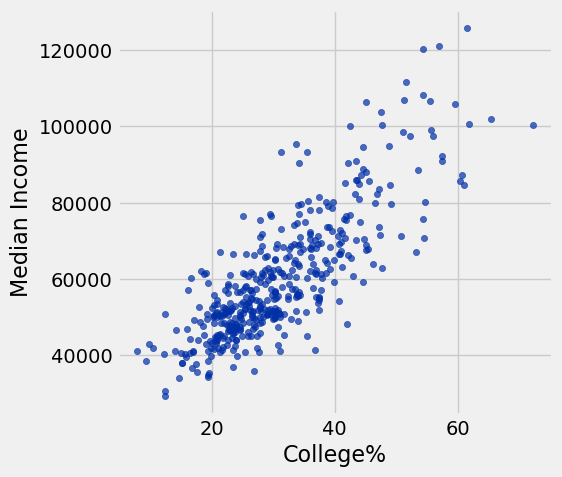

In [21]:
# COMPLETE: Compare College% and Median Income in a scatter. 

demographics_new.scatter('College%', 'Median Income')

In [22]:
# COMPLETE: Find the correlation coefficient, r, of the data in the scatter. 

correlation(demographics_new, 'College%', 'Median Income')

0.81846485171413352

In [23]:
regression_slope = slope(demographics_new, 'College%', 'Median Income')
regression_intercept = intercept(demographics_new, 'College%', 'Median Income')
regression_slope, regression_intercept

(1270.70168946388, 20802.577766677925)

***QUESTION: How would you write these as a linear regression model?***

$y = $ 

***QUESTION: How would you interpret the slope and intercept in the context of the data?***



***QUESTION: Does the y-intercept make sense as a data point?***



In [24]:
# Fitted_values function from above returns an array of the regressions estimates at all the x values.

predicted = fitted_values(demographics_new, 'College%', 'Median Income')

In [25]:
# COMPLETE: Add the fitted values to the demographics_new table under Linear Prediction.
demographics_new = demographics_new.with_column(
    'Linear Prediction',
    predicted
)

demographics_new

Median Income,College%,Linear Prediction
47083,24,51299.4
42035,21.8,48503.9
46544,22.8,49774.6
41110,17,42404.5
51690,30.3,59304.8
61413,36.7,67437.3
34664,19.4,45454.2
76440,29.6,58415.3
50537,24.5,51934.8
49072,34,64006.4


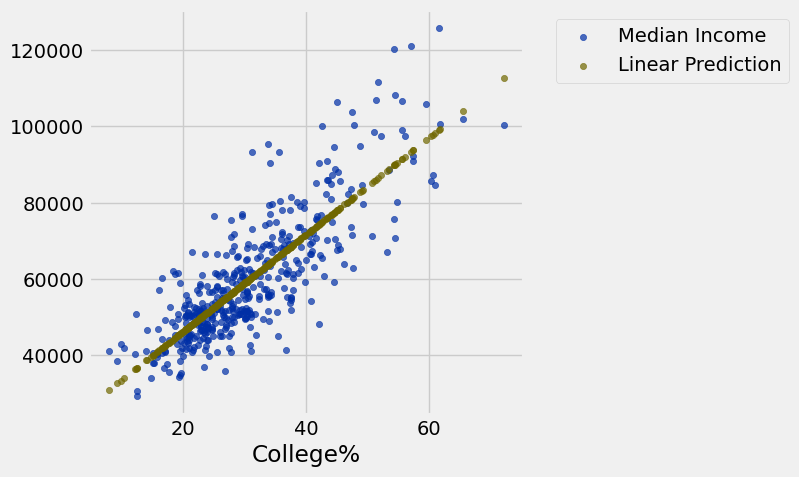

In [26]:
# COMPLETE: Create a scatter of the College%.
demographics_new.scatter('College%')

In [27]:
# Measuring the errors. 

actual = demographics_new.column('Median Income')
errors = actual - predicted

#### Measuring the Errors

Since some of the predictions are above the observed values and some are below, we will take the mean of the squared errors to avoid cancellation. 
Then take the square root of the mean of the squared errors to get the root mean squared error (RMSE). 

This is the value we want to minimize. 

In [29]:
# COMPLETE: Add the errors column to the demographics_new table. Do not reassign.

demographics_new.with_column('Errors', errors)

Median Income,College%,Linear Prediction,Errors
47083,24,51299.4,-4216.42
42035,21.8,48503.9,-6468.87
46544,22.8,49774.6,-3230.58
41110,17,42404.5,-1294.51
51690,30.3,59304.8,-7614.84
61413,36.7,67437.3,-6024.33
34664,19.4,45454.2,-10790.2
76440,29.6,58415.3,18024.7
50537,24.5,51934.8,-1397.77
49072,34,64006.4,-14934.4


In [30]:
# COMPLETE: Find the mean of the errors

np.mean(errors)

6.3560089503211536e-13

In [31]:
# COMPLETE: Take the square root of the mean of the errors squared. 

np.sqrt(np.mean(errors ** 2))

9398.5155885712811

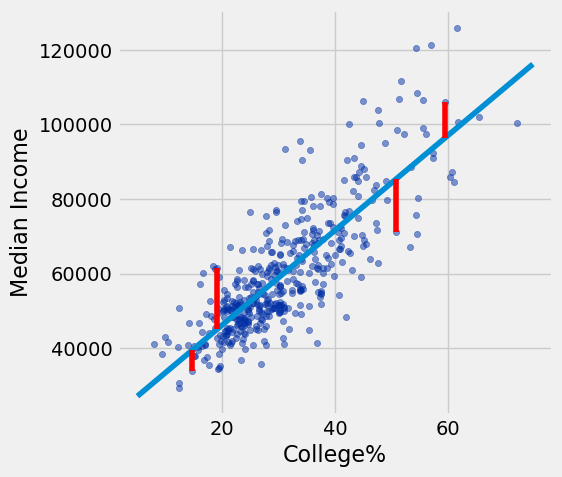

In [32]:
# Visualizing the errors. Using the linear regression line. 

demographics_errors(regression_slope, regression_intercept)

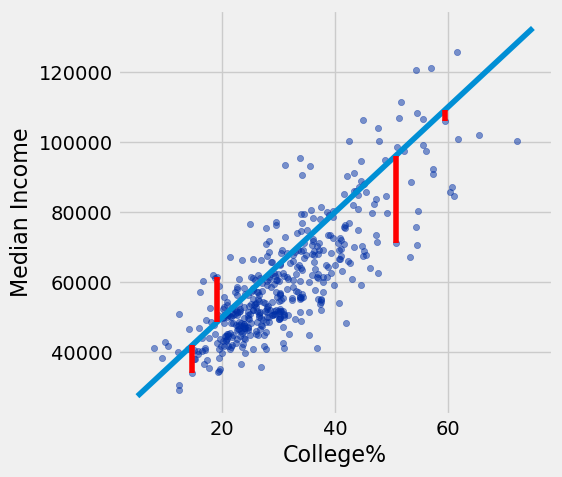

In [33]:
# Takes any slope, any intercept. Using a different slope and y-intercept.

demographics_errors(1500, 20000)

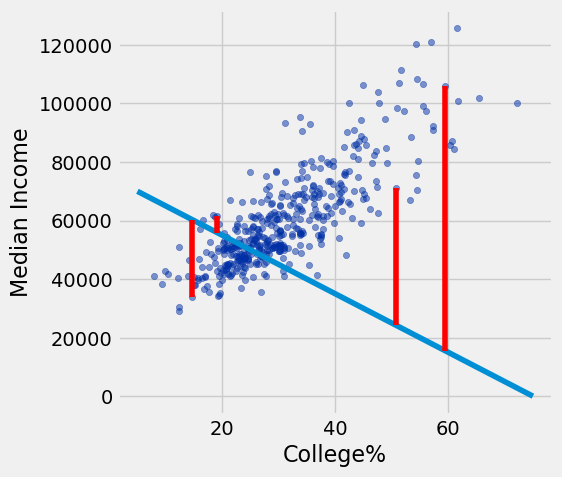

In [34]:
# Another slope and y intercept. 

demographics_errors(-1000, 75000)

### Root Mean Square Error ###

We want the regression line that gives us the smallest Root Mean Square Error (RMSE).

Root mean squared error: 30247.88


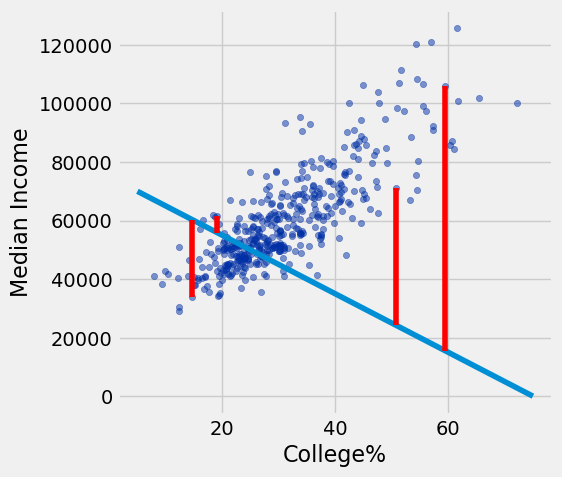

In [35]:
# Measure the error from the given line. Function defined above. 

show_demographics_rmse(-1000, 75000)

Root mean squared error: 11559.09


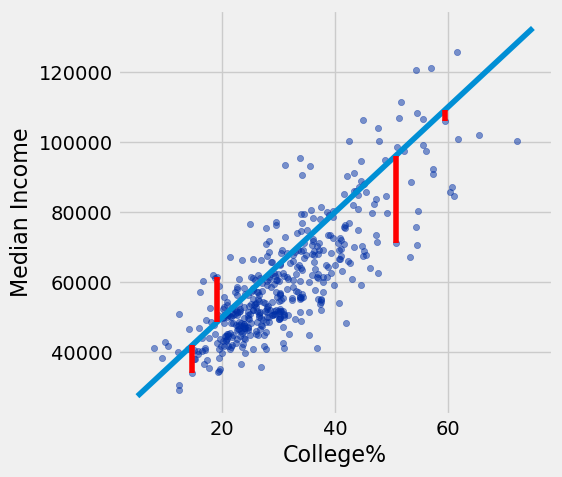

In [36]:
show_demographics_rmse(1500, 20000)

Root mean squared error: 9398.52


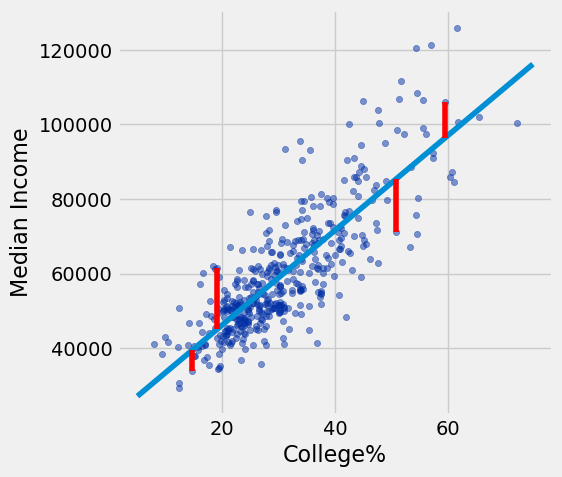

In [37]:
# Using the slope and intercept of the regression line gives the least error. 
show_demographics_rmse(regression_slope, regression_intercept)

### Numerical Optimization ###

Optimization, typically learned in PreCalculus and Calculus, allows us to find the maximum or minimum value of a function. </br>
We want to minimize the error or the root mean squared error (RMSE).

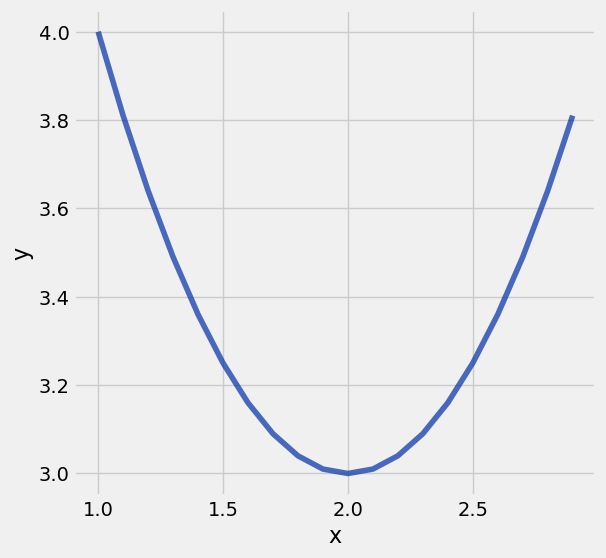

In [38]:
x = np.arange(1, 3, 0.1)
y = (x-2)**2 + 3
Table().with_columns('x', x, 'y', y).plot('x')

In [39]:
def f(x):
    return ((x-2)**2) + 3

In [40]:
minimize(f)

1.9999999946252267

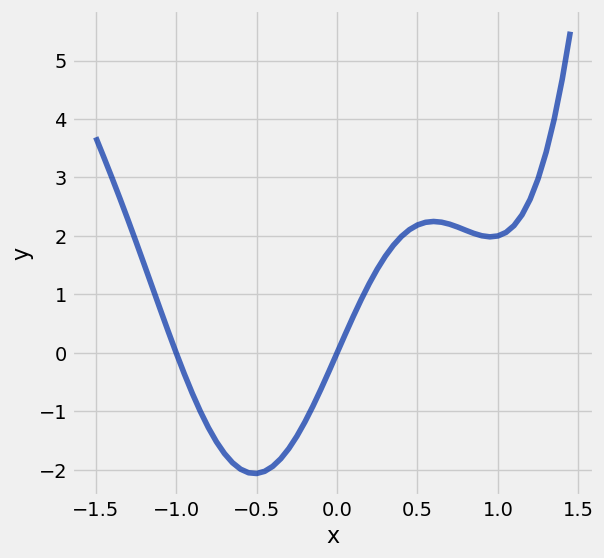

In [41]:
x = np.arange(-1.5, 1.5, 0.05)
y2 = 2 * np.sin(x*np.pi) + x ** 3 + x ** 4 
Table().with_columns('x', x, 'y', y2).plot('x')

In [42]:
def complicated_function(x):
    return 2 * np.sin(x*np.pi) + x ** 3 + x ** 4

In [43]:
minimize(complicated_function)

-0.5126437620940081

### Minimizing RMSE ###

In [44]:
# Creating a function that will take in any slope and intercept and find the minimum error based on that estimate. 
def demographics_rmse(any_slope, any_intercept):
    x = demographics.column('College%')
    y = demographics.column('Median Income')
    estimate = any_slope*x + any_intercept
    return np.sqrt(np.mean((y - estimate) ** 2))

In [45]:
demographics_rmse(1500, 20000)

11559.086490075999

In [46]:
demographics_rmse(-1000, 75000)

30247.883767944502

In [47]:
# Minimizing all possible values

minimize(demographics_rmse)

array([  1270.70168805,  20802.57933807])

In [49]:
# Compare to the regression line slope and intercept.
make_array(regression_slope, regression_intercept)

array([  1270.70168946,  20802.57776668])

***QUESTION: How would you write this as a linear regression model?***

$y= ...$

Interpret the slope and intercept in the context of the data. 


### Nonlinear Regression ###

We can find a best fit line for non linear data, it may not be in the form $y=mx+b$. </br>
Some typical forms could be:

* quadratic: $y=ax^2 + bx+ c$
* Cubic: $y=ax^3 + bx^2+ cx+d$

Import the data of a shotput data and describe the table.  

In [50]:
shotput = Table.read_table('shotput.csv')
shotput

Weight Lifted,Shot Put Distance
37.5,6.4
51.5,10.2
61.3,12.4
61.3,13
63.6,13.2
66.1,13
70,12.7
92.7,13.9
90.5,15.5
90.5,15.8


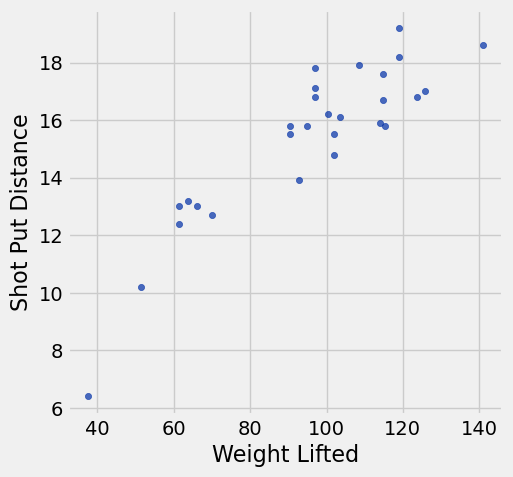

In [52]:
# COMPLETE: Create a scatter plot of Weight Lifted.

shotput.scatter('Weight Lifted')

In [53]:
# What does this function do?
def shotput_linear_rmse(any_slope, any_intercept):
    x = shotput.column('Weight Lifted')
    y = shotput.column('Shot Put Distance')
    estimate = any_slope*x + any_intercept
    return np.sqrt(np.mean((y - estimate) ** 2))

In [54]:
best_line = minimize(shotput_linear_rmse)
best_line

array([ 0.09834382,  5.95962883])

In [55]:
weights = shotput.column(0)
weights

array([  37.5,   51.5,   61.3,   61.3,   63.6,   66.1,   70. ,   92.7,
         90.5,   90.5,   94.8,   97. ,   97. ,   97. ,  102. ,  102. ,
        103.6,  100.4,  108.4,  114. ,  115.3,  114.9,  114.7,  123.6,
        125.8,  119.1,  118.9,  141.1])

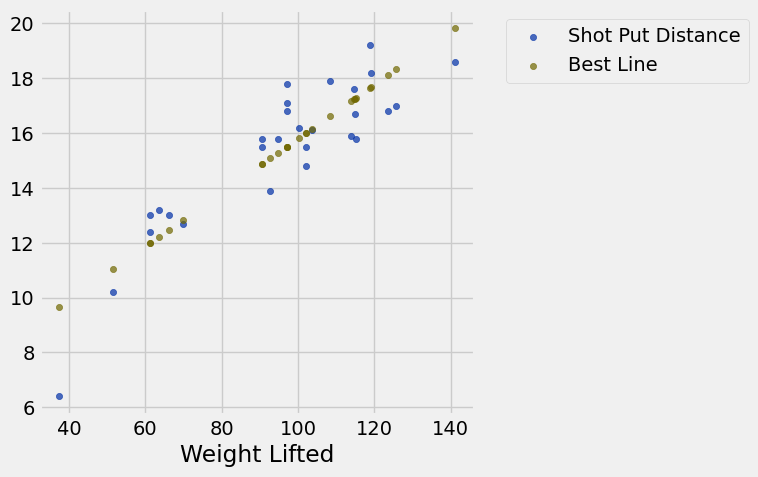

In [56]:
linear_fit = best_line.item(0)*weights + best_line.item(1)

shotput.with_column(
    'Best Line', linear_fit
).scatter(0)

**Let's try a Quadratic Function**

$$
f(x) ~=~ ax^2 + bx + c
$$
for constants $a$, $b$, and $c$.



In [57]:
def shotput_quadratic_rmse(a, b, c):
    x = shotput.column('Weight Lifted')
    y = shotput.column('Shot Put Distance')
    estimate = a*(x**2) + b*x + c
    return np.sqrt(np.mean((y - estimate) ** 2))

In [58]:
best_quad = minimize(shotput_quadratic_rmse)
best_quad

array([ -1.04003731e-03,   2.82706003e-01,  -1.53167618e+00])

In [59]:
# x = weight lifted = 100 kg
# Then predicted shot put distance:

(-0.00104)*(100**2) + 0.2827*100 - 1.5318

16.3382

In [60]:
quad_fit = best_quad.item(0)*(weights**2) + best_quad.item(1)*weights + best_quad.item(2)

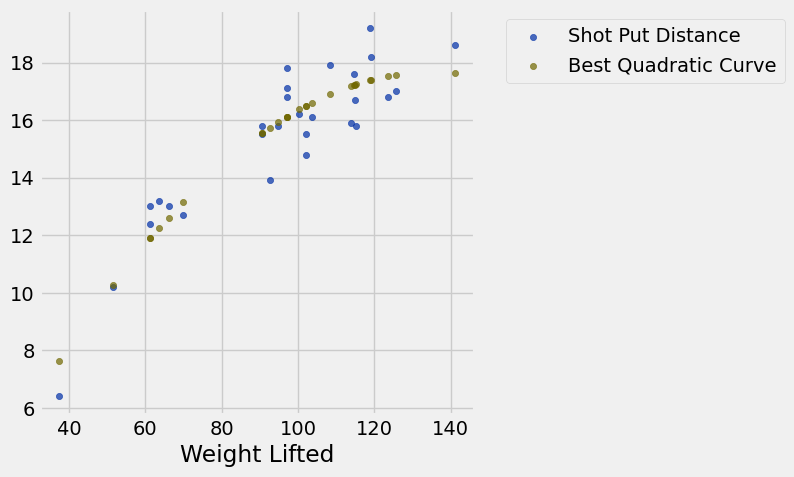

In [61]:
shotput.with_column('Best Quadratic Curve', quad_fit).scatter(0)